# FCPO Analysis Notebook
Interactive exploration of FCPO spot price + term structure data.

In [82]:
import matplotlib
matplotlib.use('inline')
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

from FCPO_analysis import (
    load_combined_dataset, enrich_dataset,
    load_spot_prices, load_contracts,
    build_daily_curves, load_supply_demand,
    spot_summary, curve_shape_stats, tenor_spreads, monthly_returns,
    plot_spot_yoy, plot_curve_snapshot, plot_spread_history,
    plot_monthly_seasonality, plot_monthly_close_heatmap,
    sd_summary, sd_price_correlation, plot_sd_vs_price
)
print('Ready.')

Ready.


## 1. Load Data

In [83]:
df = load_combined_dataset()   # spot OHLCV + all 12 tenors, 1 row per trading day
print(f'{len(df)} rows | {df["date"].min().date()} → {df["date"].max().date()}')
df.head(10)

1516 rows | 2020-01-02 → 2026-03-10


,date,Current,+1M,+2M,+3M,+4M,+5M,+6M,+7M,+8M,+9M,+10M,+11M,current_filled,open,high,low,close,volume,year,month,doy,weekday
0,2020-01-02,"3,125.00",3141,3126,3102,3065,3019,2970,2919,2878,2855,"2,843.00","2,854.00",False,"3,140.00","3,149.00","3,069.00","3,116.00","22,159.00",2020,1,2,Thursday
1,2020-01-03,"3,110.00",3126,3117,3099,3056,3009,2951,2909,2867,2848,"2,832.00","2,837.00",False,"3,140.00","3,149.00","3,069.00","3,116.00","22,159.00",2020,1,3,Friday
2,2020-01-06,"3,060.00",3054,3044,3036,3006,2966,2917,2863,2820,2795,"2,785.00","2,797.00",False,"3,046.00","3,085.00","3,013.00","3,042.00","29,611.00",2020,1,6,Monday
3,2020-01-07,"3,040.00",3054,3047,3037,3009,2962,2914,2864,2818,2798,"2,774.00","2,788.00",False,"3,047.00","3,059.00","3,024.00","3,041.00","18,328.00",2020,1,7,Tuesday
4,2020-01-08,"3,043.00",3053,3038,3021,2992,2951,2900,2857,2818,2785,"2,773.00","2,775.00",False,"3,038.00","3,124.00","3,038.00","3,110.00","24,034.00",2020,1,8,Wednesday
5,2020-01-09,"3,120.00",3120,3113,3085,3040,2996,2943,2913,2855,2842,"2,806.00","2,820.00",False,"3,100.00","3,150.00","3,088.00","3,134.00","16,975.00",2020,1,9,Thursday
6,2020-01-10,"3,132.00",3147,3136,3112,3073,3026,2971,2930,2882,2857,"2,830.00","2,840.00",False,"3,100.00","3,150.00","3,088.00","3,134.00","16,975.00",2020,1,10,Friday
7,2020-01-13,"3,106.00",3106,3091,3061,3012,2967,2914,2876,2838,2823,"2,806.00","2,800.00",True,"3,064.00","3,075.00","3,004.00","3,005.00","23,101.00",2020,1,13,Monday
8,2020-01-14,"3,030.00",3032,3005,2979,2937,2892,2849,2809,2780,2763,"2,737.00","2,737.00",False,"3,021.00","3,038.00","2,943.00","2,945.00","27,726.00",2020,1,14,Tuesday
9,2020-01-15,"3,030.00",2982,2945,2909,2870,2830,2785,2744,2720,2711,"2,694.00","2,700.00",False,"2,880.00","2,926.00","2,877.00","2,886.00","23,749.00",2020,1,15,Wednesday


In [84]:
# Quick column overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516 entries, 0 to 1515
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            1516 non-null   datetime64[ns]
 1   Current         1516 non-null   float64       
 2   +1M             1516 non-null   int64         
 3   +2M             1516 non-null   int64         
 4   +3M             1516 non-null   int64         
 5   +4M             1516 non-null   int64         
 6   +5M             1516 non-null   int64         
 7   +6M             1516 non-null   int64         
 8   +7M             1516 non-null   int64         
 9   +8M             1516 non-null   int64         
 10  +9M             1516 non-null   int64         
 11  +10M            1509 non-null   float64       
 12  +11M            1421 non-null   float64       
 13  current_filled  1516 non-null   bool          
 14  open            1516 non-null   float64       
 15  high

In [85]:
# Descriptive stats for price columns
df[['close','Current','+1M','+3M','+6M','+11M']].describe().round(0)

,close,Current,+1M,+3M,+6M,+11M
count,"1,516.00","1,516.00","1,516.00","1,516.00","1,516.00","1,421.00"
mean,"3,989.00","4,109.00","4,053.00","3,936.00","3,833.00","3,752.00"
std,848.00,950.00,901.00,809.00,756.00,730.00
min,"1,946.00","2,000.00","1,957.00","1,950.00","2,009.00","2,166.00"
25%,"3,693.00","3,719.00","3,715.00","3,643.00","3,552.00","3,488.00"
50%,"3,950.00","4,009.00","3,976.00","3,932.00","3,919.00","3,858.00"
75%,"4,318.00","4,427.00","4,386.00","4,261.00","4,160.00","4,089.00"
max,"7,104.00","8,170.00","7,624.00","6,752.00","6,323.00","6,138.00"


## 2. Spot Price Summary

In [86]:
df_spot = load_spot_prices()
spot_summary(df_spot)

,Trading Days,Open (YTD),Latest Close,Min,Max,Mean,Std Dev,Ann. Volatility,YTD Return
Year,,,,,,,,,
2020,201,3130,3600,1946,3600,"2,698.00",406.00,39.7%,+15.0%
2021,199,3755,4697,3221,5071,"4,156.00",498.00,40.8%,+25.1%
2022,202,4914,4174,3226,7104,"4,925.00","1,070.00",59.6%,-15.1%
2023,200,4253,3721,3201,4352,"3,790.00",210.00,32.3%,-12.5%
2024,200,3660,4448,3621,5135,"4,122.00",378.00,26.7%,+21.5%
2025,191,4368,4050,3728,4672,"4,231.00",225.00,24.2%,-7.3%
2026,32,3991,4157,3980,4317,"4,106.00",92.00,20.0%,+4.2%


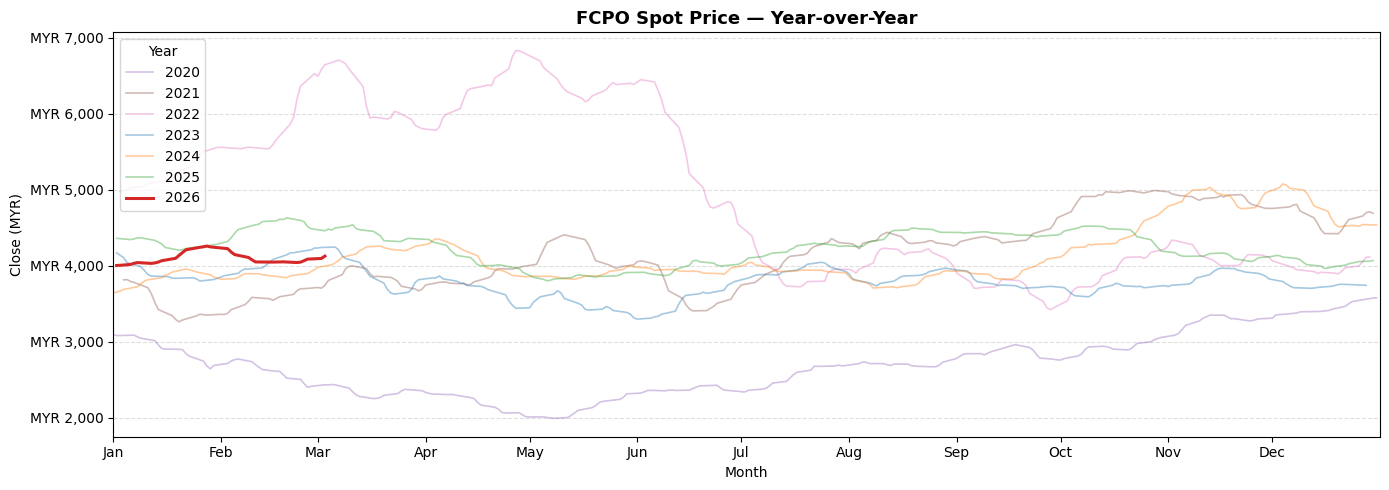

In [87]:
plot_spot_yoy(df_spot)
plt.show()

## 3. Term Structure

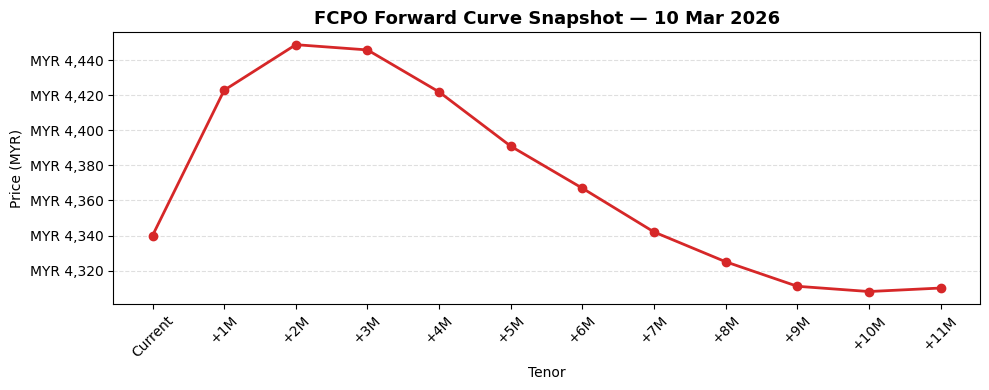

In [88]:
# Latest forward curve snapshot
contracts = load_contracts()
df_curves = build_daily_curves(contracts)
plot_curve_snapshot(df_curves)
plt.show()

In [89]:
# Contango vs backwardation history
shape = curve_shape_stats(df_curves)
print(shape['shape'].value_counts())
shape.tail(10)

shape
Backwardation    1019
Contango          452
Name: count, dtype: int64


,Date,Current,+3M,spread_3m,shape
1461,2026-02-24,"4,017.00",4053,36.00,Contango
1462,2026-02-25,"4,018.00",4052,34.00,Contango
1463,2026-02-26,"3,955.00",4007,52.00,Contango
1464,2026-02-27,"3,988.00",4047,59.00,Contango
1465,2026-03-02,"4,051.00",4151,100.00,Contango
1466,2026-03-03,"4,070.00",4195,125.00,Contango
1467,2026-03-04,"4,070.00",4187,117.00,Contango
1468,2026-03-05,"4,078.00",4217,139.00,Contango
1469,2026-03-06,"4,240.00",4373,133.00,Contango
1470,2026-03-10,"4,340.00",4446,106.00,Contango


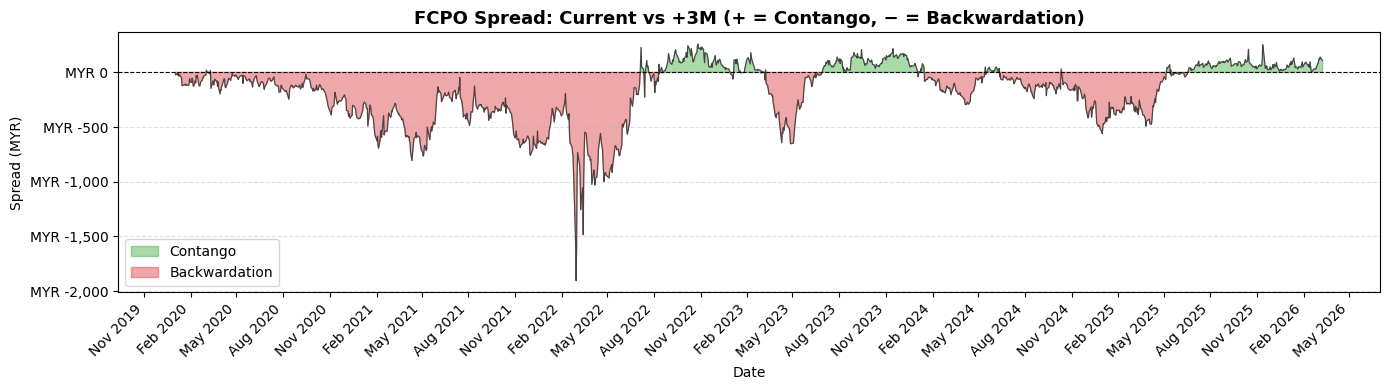

In [90]:
plot_spread_history(df_curves, tenor='+3M')
plt.show()

## 4. Seasonality

In [91]:
monthly_returns(df_spot)

,month,avg_return,std_return,count
month_name,,,,
Jan,1,-1.78,10.48,7
Feb,2,5.45,11.52,7
Mar,3,-3.08,8.14,7
Apr,4,-4.37,13.73,6
May,5,1.37,8.34,6
Jun,6,-4.12,13.21,6
Jul,7,5.04,7.95,6
Aug,8,2.03,1.35,6
Sep,9,-1.67,6.35,6


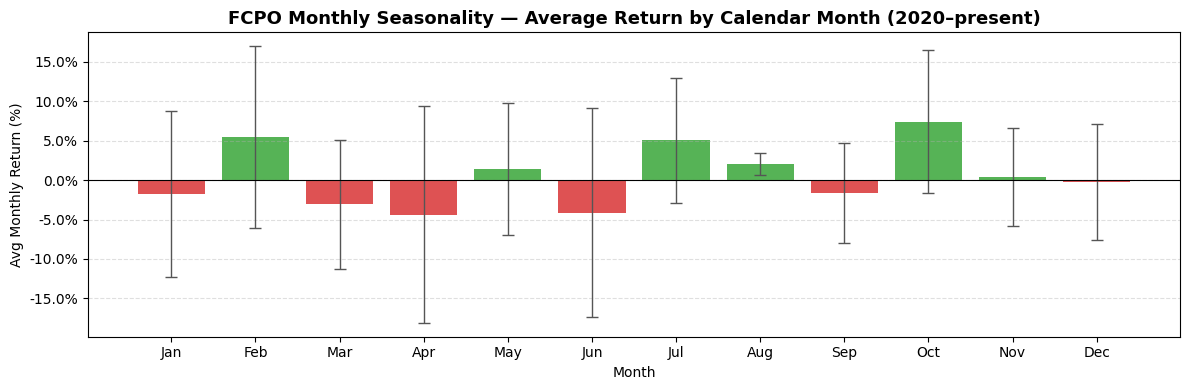

In [92]:
plot_monthly_seasonality(df_spot)
plt.show()

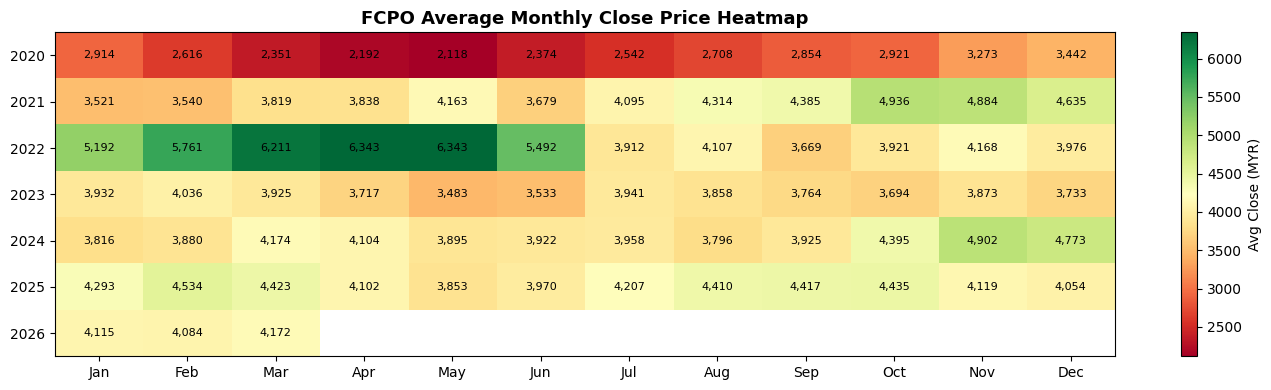

In [93]:
plot_monthly_close_heatmap(df_spot)
plt.show()

## 5. Supply & Demand

In [94]:
df_sd = load_supply_demand()
sd_summary(df_sd)

,2026 YTD,2025 YTD,YoY Change
Metric,,,
Production,"1,577,454","20,282,486",-92.2%
Exports,"1,484,267","15,285,877",-90.3%
Stock,"2,815,493","25,604,228",-89.0%
Consumption,"328,841","3,654,218",-91.0%


In [95]:
sd_price_correlation(df_spot, df_sd)

,Production,Exports,Stock,Consumption,Spot Price
Production,1.00,0.61,0.57,0.12,0.01
Exports,0.61,1.00,0.25,-0.30,0.17
Stock,0.57,0.25,1.00,0.36,-0.05
Consumption,0.12,-0.30,0.36,1.00,-0.15
Spot Price,0.01,0.17,-0.05,-0.15,1.00


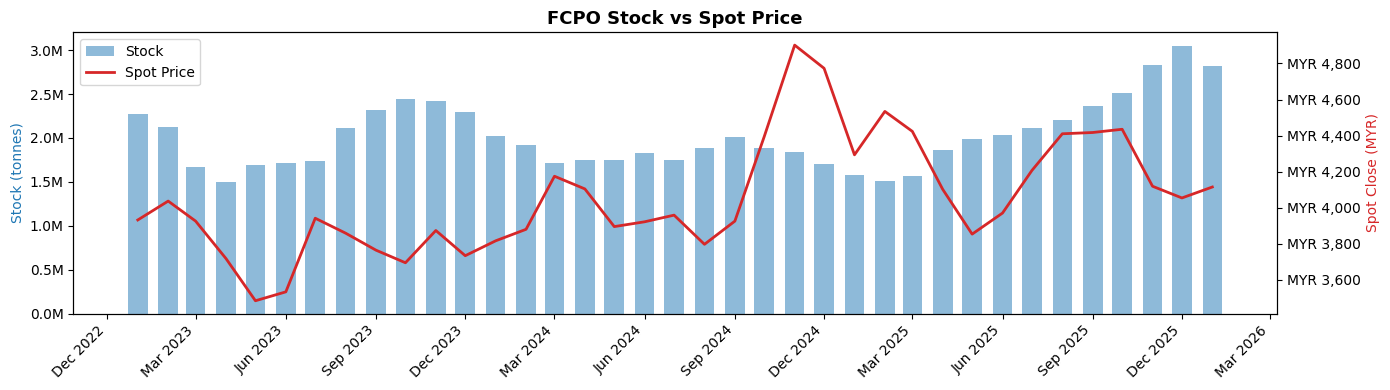

In [96]:
plot_sd_vs_price(df_spot, df_sd, metric='Stock')
plt.show()

## 7. Enriched Daily Dataset\nAdds: `term_shape`, `spread_3m`, day-over-day % changes, `open_close`, `high_low`

In [97]:
df_rich = enrich_dataset(load_combined_dataset())
print(f'{len(df_rich)} rows | columns added: term_shape, spread_3m, dod_*_pct, open_close, high_low')
df_rich.tail(3)

1516 rows | columns added: term_shape, spread_3m, dod_*_pct, open_close, high_low


,date,Current,+1M,+2M,+3M,+4M,+5M,+6M,+7M,+8M,+9M,+10M,+11M,current_filled,open,high,low,close,volume,year,month,doy,weekday,spread_3m,term_shape,dod_close_pct,dod_Current_pct,dod_1m_pct,dod_2m_pct,dod_3m_pct,dod_4m_pct,dod_5m_pct,dod_6m_pct,dod_7m_pct,dod_8m_pct,dod_9m_pct,dod_10m_pct,dod_11m_pct,open_close,high_low
1513,2026-03-06,"4,240.00",4332,4365,4373,4362,4345,4329,4320,4309,4305,"4,300.00","4,290.00",False,"4,188.00","4,205.00","4,143.00","4,157.00","20,286.00",2026,3,65,Friday,133.00,Contango,0.00,3.97,3.64,3.80,3.70,3.44,3.26,3.07,3.08,2.84,2.65,3.24,2.58,31.00,62.00
1514,2026-03-09,"4,541.00",4541,4570,4565,4539,4505,4471,4437,4410,4385,"4,374.00","4,332.00",True,"4,188.00","4,205.00","4,143.00","4,157.00","20,286.00",2026,3,68,Monday,24.00,Contango,0.00,7.10,4.82,4.70,4.39,4.06,3.68,3.28,2.71,2.34,1.86,1.72,0.98,31.00,62.00
1515,2026-03-10,"4,340.00",4423,4449,4446,4422,4391,4367,4342,4325,4311,"4,308.00","4,310.00",False,"4,188.00","4,205.00","4,143.00","4,157.00","20,286.00",2026,3,69,Tuesday,106.00,Contango,0.00,-4.43,-2.60,-2.65,-2.61,-2.58,-2.53,-2.33,-2.14,-1.93,-1.69,-1.51,-0.51,31.00,62.00


In [ ]:
# Term shape overview
key_cols = ['date', 'close', 'em_avg', 'fm_avg', 'em_fm_spread', 'term_shape',
            'open_close', 'high_low', 'dod_close_pct', 'dod_Current_pct']
df_rich[key_cols].tail(20)

In [99]:
# Day-over-day % changes — spot close + all 12 tenors
dod_cols = ['date', 'term_shape', 'dod_close_pct',
            'dod_Current_pct', 'dod_1m_pct', 'dod_2m_pct', 'dod_3m_pct',
            'dod_4m_pct', 'dod_5m_pct', 'dod_6m_pct', 'dod_7m_pct',
            'dod_8m_pct', 'dod_9m_pct', 'dod_10m_pct', 'dod_11m_pct']
df_rich[dod_cols].tail(20).style.format({c: '{:+.2f}%' for c in dod_cols[2:]}, na_rep='-')

,date,term_shape,dod_close_pct,dod_Current_pct,dod_1m_pct,dod_2m_pct,dod_3m_pct,dod_4m_pct,dod_5m_pct,dod_6m_pct,dod_7m_pct,dod_8m_pct,dod_9m_pct,dod_10m_pct,dod_11m_pct
1496,2026-02-09 00:00:00,Contango,-1.42%,+0.44%,+0.29%,+0.22%,+0.10%,+0.07%,-0.05%,+0.00%,+0.00%,+0.15%,+0.10%,-0.05%,-0.41%
1497,2026-02-10 00:00:00,Contango,-0.83%,-1.22%,-1.48%,-1.56%,-1.54%,-1.47%,-1.40%,-1.47%,-1.40%,-1.46%,-1.51%,-1.60%,-1.78%
1498,2026-02-11 00:00:00,Contango,-0.59%,-1.23%,-0.91%,-0.90%,-0.73%,-0.66%,-0.51%,-0.37%,-0.37%,-0.17%,-0.12%,+0.07%,+0.35%
1499,2026-02-12 00:00:00,Contango,+0.32%,+0.00%,-0.57%,-0.57%,-0.66%,-0.81%,-0.91%,-0.91%,-0.86%,-0.91%,-0.72%,-0.77%,-0.72%
1500,2026-02-13 00:00:00,Contango,+0.00%,-1.25%,+0.65%,+0.32%,+0.00%,+0.00%,+0.05%,+0.02%,+0.15%,+0.27%,+0.07%,+0.02%,-0.25%
1501,2026-02-16 00:00:00,Backwardation,-0.84%,+1.54%,-0.45%,-0.89%,-0.87%,-0.79%,-0.57%,-0.57%,-0.62%,-0.72%,-0.50%,+0.00%,+0.00%
1502,2026-02-19 00:00:00,Contango,+1.89%,+2.07%,+2.36%,+2.57%,+2.59%,+2.59%,+2.37%,+2.50%,+2.57%,+2.57%,+2.62%,+2.31%,+0.00%
1503,2026-02-20 00:00:00,Contango,+0.00%,-0.73%,-0.70%,-0.66%,-0.51%,-0.36%,-0.19%,-0.12%,-0.17%,-0.05%,-0.02%,-0.12%,+0.00%
1504,2026-02-23 00:00:00,Contango,-0.95%,-0.22%,-0.10%,-0.15%,-0.27%,-0.49%,-0.59%,-0.68%,-0.68%,-0.78%,-0.56%,-0.93%,+1.60%
1505,2026-02-24 00:00:00,Contango,+0.00%,-0.94%,-0.81%,-0.73%,-0.73%,-0.54%,-0.64%,-0.69%,-0.79%,-0.71%,-0.81%,-0.29%,-0.12%


In [100]:
# Intraday range: open-close and high-low
df_rich[['date', 'open', 'high', 'low', 'close',
         'open_close', 'high_low', 'term_shape']].tail(20)

,date,open,high,low,close,open_close,high_low,term_shape
1496,2026-02-09,"4,168.00","4,175.00","4,085.00","4,095.00",73.00,90.00,Contango
1497,2026-02-10,"4,102.00","4,125.00","4,053.00","4,061.00",41.00,72.00,Contango
1498,2026-02-11,"4,080.00","4,087.00","4,021.00","4,037.00",43.00,66.00,Contango
1499,2026-02-12,"4,038.00","4,059.00","3,990.00","4,050.00",-12.00,69.00,Contango
1500,2026-02-13,"4,038.00","4,059.00","3,990.00","4,050.00",-12.00,69.00,Contango
1501,2026-02-16,"4,050.00","4,075.00","4,008.00","4,016.00",34.00,67.00,Backwardation
1502,2026-02-19,"4,119.00","4,156.00","4,078.00","4,092.00",27.00,78.00,Contango
1503,2026-02-20,"4,119.00","4,156.00","4,078.00","4,092.00",27.00,78.00,Contango
1504,2026-02-23,"4,084.00","4,116.00","4,040.00","4,053.00",31.00,76.00,Contango
1505,2026-02-24,"4,047.00","4,088.00","4,035.00","4,053.00",-6.00,53.00,Contango


In [101]:
# Scratch — your own analysis here
